In [22]:
import pandas as pd

df = pd.read_csv('train.csv', encoding='latin1')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head()

Shape: (9800, 18)

Column names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [23]:
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n")
df.describe()

Data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Descriptive statistics:



,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [24]:
# Postal Code ki missing values fill karo
df['Postal Code'] = df['Postal Code'].fillna(0)

# Order Date aur Ship Date ko proper date format mein convert karo
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Check karo ki convert ho gaya
print(df[['Order Date', 'Ship Date']].dtypes)
print(df[['Order Date', 'Ship Date']].head())

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


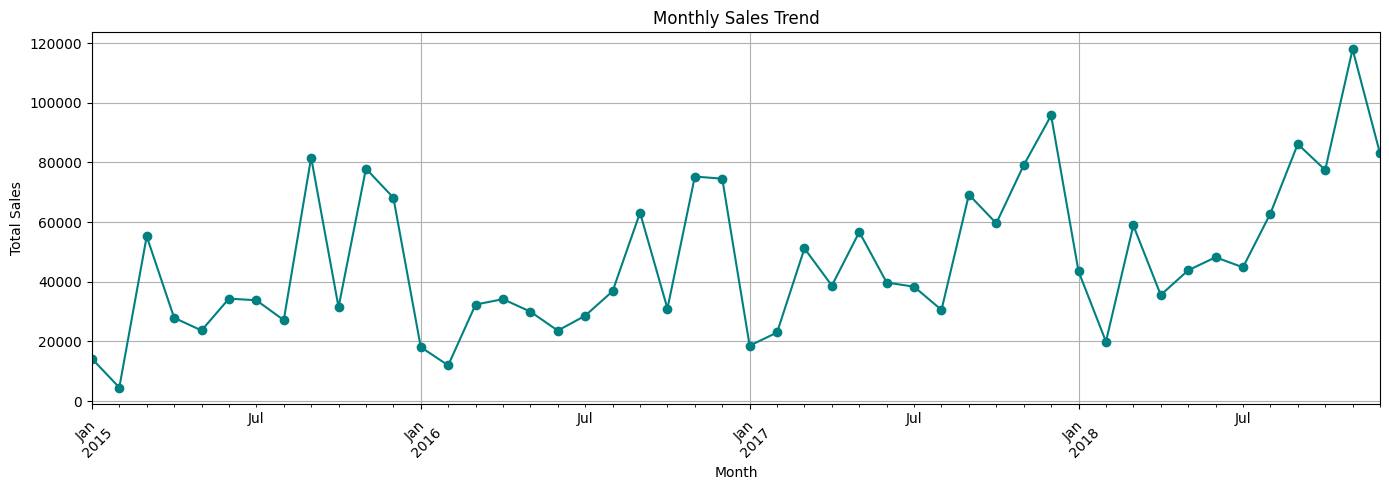

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation: Monthly Sales Trend
Sales data mein clear seasonality dikhti hai — November aur December mahino mein
sales sabse zyada hoti hai, jo holiday season shopping ki wajah se ho sakta hai.
Beech ke mahino (Jan-Aug) mein sales fluctuate karti rehti hai lekin overall
ek upward trend dikhta hai saalon ke saath.

Top 10 Products:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


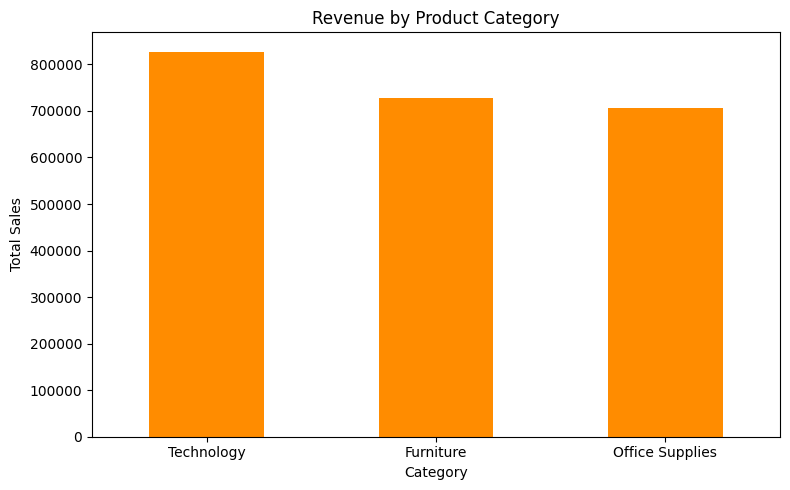

In [26]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products:\n", top_products)

category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='darkorange')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation: Product & Category Analysis
Technology category sabse zyada revenue generate karti hai (~₹8.3 lakh),
uske baad Furniture aur Office Supplies. Top-selling products mostly office
equipment (copiers, binding machines) hain jo bulk/corporate orders
indicate karte hain.

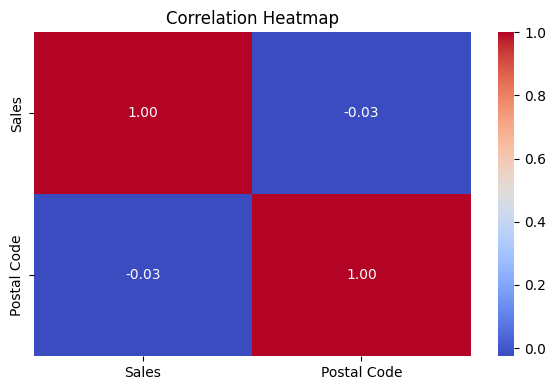

In [27]:
numeric_cols = df[['Sales', 'Postal Code']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation: Correlation Analysis
Sales aur Postal Code ke beech koi meaningful correlation nahi hai (-0.03),
jo expected hai kyunki Postal Code sirf ek location identifier hai,
sales amount ko directly influence nahi karta.

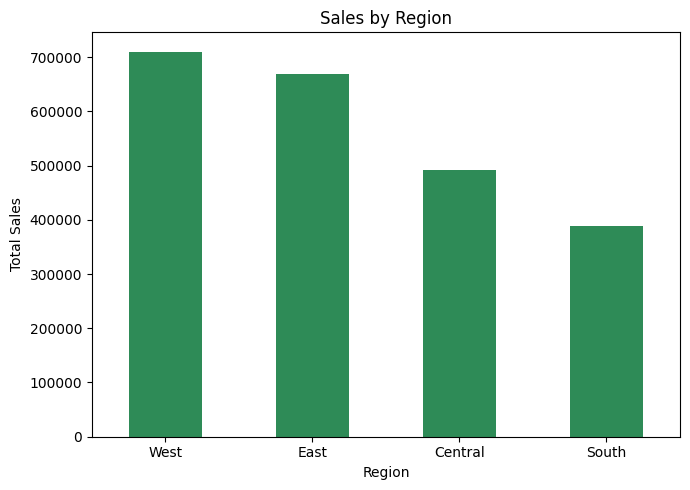

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [28]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
region_sales.plot(kind='bar', color='seagreen')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(region_sales)

### Observation: Regional Performance
West region sabse zyada sales generate karta hai (~₹7.1 lakh), uske baad
East region. South region sabse kam perform kar raha hai (~₹3.9 lakh),
jo growth opportunity indicate karta hai.

## Conclusion & Business Recommendations

Is EDA ke through humne retail sales dataset ka detailed analysis kiya.
Neeche kuch key findings aur actionable recommendations diye gaye hain:

**1. Seasonal Inventory Planning**
Sales November-December mein peak karti hai. Company ko holiday season
se pehle (October ke end tak) apna inventory stock badha lena chahiye,
especially Technology aur Office Supplies categories mein, taaki demand
miss na ho.

**2. Focus on Technology Category**
Technology category sabse zyada revenue generate karti hai. Company ko
is category mein marketing budget aur product variety badhani chahiye,
aur bundle deals (jaise printer + accessories) offer karke average
order value aur badha sakte hain.

**3. South Region Mein Growth Opportunity**
South region sabse kam sales perform kar raha hai baaki regions ke
comparison mein. Company ko South region mein targeted marketing
campaigns, local promotions, ya regional discounts launch karne
chahiye taaki market penetration badhe.

Overall, ye analysis dikhata hai ki data-driven decisions se company
apna inventory, marketing, aur regional strategy better optimize kar
sakti hai.